In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1

## Understanding the problem

Sphere in d+1 dimensions is $x_1^2+x_2^2+...+x_d^2+x_{d+1}^2\leq1$

Thus $x_{d+1}^2\leq 1-|\vec{x}|^2$

Where $|\vec{x}|$ is d-dimensional sphere

So $-\sqrt{1-|\vec{x}|^2}\leq x_{d+1}^2\leq \sqrt{1-|\vec{x}|^2}$ 

Thus the thickness of the slice is $2\sqrt{1-|\vec{x}|^2}$

Just add up all these `spherical' slices to get volume of d+1 dimensional sphere $V_{d+1} = \int_{|\vec{x}|\leq 1}2\sqrt{1-|\vec{x}|^2} d^dx$

But here $|\vec{x}|$ is a d-dimensional sphere so the sampling of $|\vec{x}|$ points has to be done inside a d-sphere. This si much better than rejection sampling of method B as for higher dimensions, the volume of a sphere is negligible compared to volume of a cube. 

A vector where each element is sampled from a gaussian distribution can be separated into a radial and angular part. Thus a unit vector of gaussians is equivalent to a uniformly distributed point on a sphere. To sample inside the sphere, we multiply with $U^{1/d}$ evident by inverse CDF since volume of a d-sphere is $\propto r^d$.

1. Sample a gaussian distribution

Box-Muller gives 2 gaussian sampled variables as $X= \sqrt{-2\ln{U_1}}\cos(2\pi U_2)$ and $Y= \sqrt{-2\ln{U_1}}\sin(2\pi U_2)$

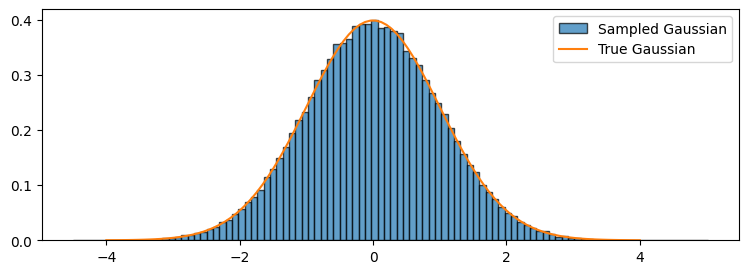

In [2]:
N = 100000
rng = np.random.default_rng()
U1 = rng.uniform(low=0, high=1, size=N)
U2 = rng.uniform(low=0, high=1, size=N)
G = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)

fig, ax= plt.subplots(1,1,figsize=(9,3))
ax.hist(G, bins=100, edgecolor='k', alpha=0.7, density=True, label='Sampled Gaussian');
x = np.linspace(-4,4,100)
y = (1/np.sqrt(2*np.pi))*np.exp(-x**2/2)
ax.plot(x,y, label='True Gaussian')
ax.legend();

2. Sample uniformly on d-sphere surface and volume

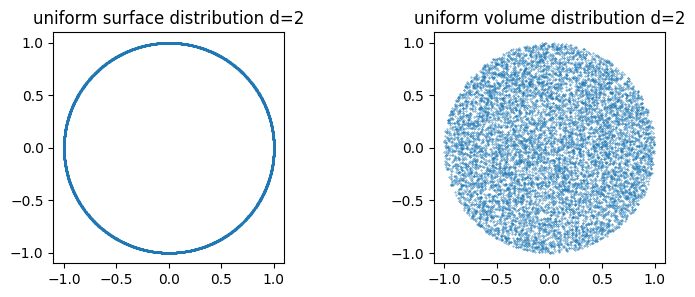

In [82]:
def ball_sampler(d, N):

    U1 = rng.uniform(low=0, high=1, size=d*N)
    U2 = rng.uniform(low=0, high=1, size=d*N)

    Z = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)

    # Each row of Z is a gaussian vector
    Z = Z.reshape(N, d)

    # Each row of norm_Z is a normalised gaussian unit vector. These are samples on surface of d-sphere
    norm_Z = Z/np.linalg.norm(Z, axis=1, keepdims=True)

    U3 = rng.uniform(low=0, high=1, size=N)
    U3 = U3.reshape(N, 1)
    
    surface_sample = norm_Z
    volume_sample = U3**(1/d)*norm_Z

    return surface_sample, volume_sample

N = 10000

# Example 2d surface and volume:
surface_points, volume_points = ball_sampler(2, N)

fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)
ax[0].scatter(surface_points[:, 0], surface_points[:, 1], s=0.1)
ax[0].set_title(label='uniform surface distribution d=2')
ax[1].scatter(volume_points[:, 0], volume_points[:,1], s=0.1); 
ax[1].set_title(label='uniform volume distribution d=2');

3. Monte Carlo volume estimate for d+1 sphere given volume of d-sphere

In [111]:
def next_volume(d, N, true_Vd):

    surf_pt, vol_pt = ball_sampler(d, N)

    Vd = true_Vd[d-1]

    return 2*Vd*np.sum(np.sqrt(1-np.linalg.norm(vol_pt, axis=1)**2))/N

true_vd = [2, np.pi, 4*np.pi/3, np.pi**2/2, 8*np.pi**2/15, np.pi**3/6, 16*np.pi**3/105, np.pi**4/24]

for d in range(1,7):
    print(f'd+1={d+1}, MC: {next_volume(d, 1000000, true_vd)}, True: {true_vd[d]}')

d+1=2, MC: 3.1421859923466204, True: 3.141592653589793
d+1=3, MC: 4.190347313982771, True: 4.1887902047863905
d+1=4, MC: 4.932451278321208, True: 4.934802200544679
d+1=5, MC: 5.264168809715033, True: 5.263789013914324
d+1=6, MC: 5.167844997141442, True: 5.167712780049969
d+1=7, MC: 4.725543191264353, True: 4.724765970331401


4. Error plot

In [135]:
N_range = [10, 100, 1000, 10000, 100000, 1000000, 10000000]
error = np.zeros(len(N_range))
d = 3

for i in range(len(N_range)):
    mc= next_volume(d, N_range[i], true_vd)
    error[i] = np.abs(mc-true_vd[d])

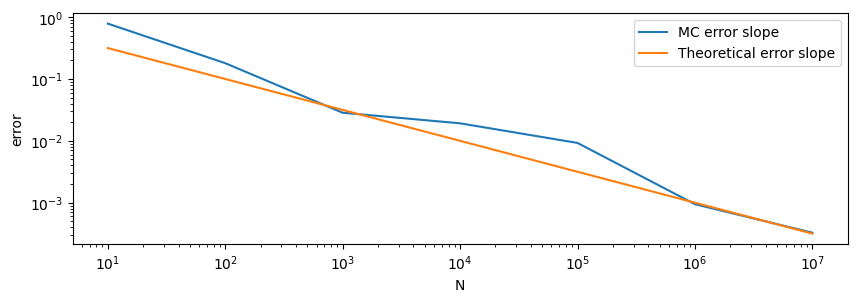

In [136]:
fig, ax = plt.subplots(1,1,figsize=(10,3))
ax.plot(N_range, error, label='MC error slope')
ax.plot(N_range, 1/np.sqrt(N_range), label='Theoretical error slope')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N');
ax.set_ylabel('error');
ax.legend();

# Problem 2

We need to sample within a -L to L 2D grid and reject points not falling on the desired probability distribution. Inside the box V=0 so we only need to consider the $U(|x_1-x_2|)$ potential.

$\pi(x)= \exp(\frac{-e^2}{kT}\cdot \frac{1/L}{|x_1/L- x_2/L|}) = \exp(\frac{\lambda}{|x_1/L- x_2/L|})$ 

Essentially we will have to sample

$\pi(x_1, x_2) = \frac{1}{Z}e^{-\lambda/|x_1-x_2|}$

We don't necessarily need the normalisation constant as that can be absorbed into the rejection constant.

$0<e^{-\lambda/|x_1-x_2|}<1$ so we can choose the ceiling as 1 for $x_1, x_2 \in [-1,1]$

Algorithm is: 

- Uniformly sample $x_1, x_2 \in [-1,1]$
- Select $u$ uniform in $[0,1]$
- accept $x_1, x_2$ if $u\leq \pi(x_1, x_2)/\pi^*$
- $\pi^*=1$ is our ceiling 

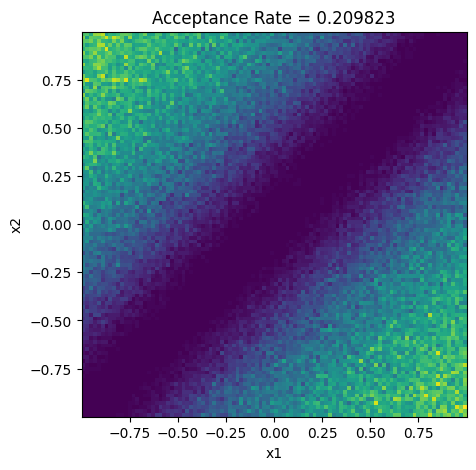

In [22]:
def pdf(l, x1, x2):
    return np.exp(-l/np.abs(x1-x2))

N = 1000000

x1 = rng.uniform(low=-1, high=1, size=N)
x2 = rng.uniform(low=-1, high=1, size=N)
u = rng.uniform(low=0, high=1, size=N)
compare = pdf(1, x1, x2)

accept_mask = np.where(u <= compare)
x1_accept = x1[accept_mask]
x2_accept = x2[accept_mask]

fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.set_box_aspect(1)
ax.hist2d(x1_accept, x2_accept, bins=100);
ax.set_xlabel('x1');
ax.set_ylabel('x2');
ax.set_title(f'Acceptance Rate = {len(x1_accept)/N}');

For average distance, since $\lambda$ is the repulsion strength, for higher repulsion, the average distance between the two particles should tend to 2 as the particles are still confined to the box.

In [30]:
def avg_dist(l, N):
    x1 = rng.uniform(low=-1, high=1, size=N)
    x2 = rng.uniform(low=-1, high=1, size=N)
    u = rng.uniform(low=0, high=1, size=N)
    compare = pdf(l, x1, x2)
    accept_mask = np.where(u <= compare)
    x1_accept = x1[accept_mask]
    x2_accept = x2[accept_mask]

    avg_dist = np.average(np.abs(x1_accept-x2_accept))

    return avg_dist

# L=1
l_vals = np.linspace(0, 10, 50)
d_vals = np.zeros(len(l_vals))
d_vals[0] = 2/3

for i in range(1, len(l_vals)):
    d_vals[i] = avg_dist(l_vals[i], N)

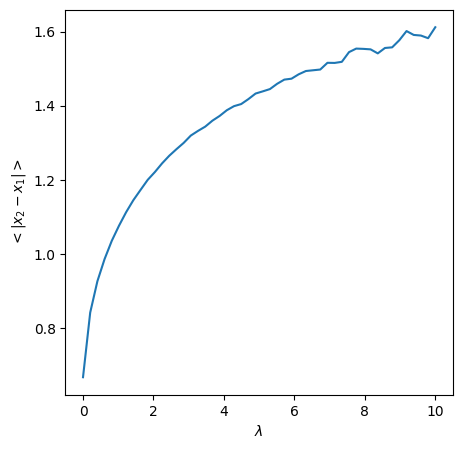

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(l_vals, d_vals)
ax.set_xlabel(r'$\lambda$');
ax.set_ylabel(r'$<|x_2-x_1|>$');